# 🌾 Crop Classification v2 — Hisar District
## Two-Stage Hierarchical Approach (GEE + scikit-learn)

**Stage 1:** Cropland mask via NDVI threshold + ESA WorldCover mask  
**Stage 2:** Phenological rules (auto-label) + manual tree training + Random Forest  

**Classes:** Cotton, Rice, Bajra, Fallow, Trees/Orchards, Pulses (6 classes)  
**Features:** 48 bands (NDVI + NDWI + RENDVI × 16 fortnights, April–November)  
**Cloud masking:** QA60 + SCL (catches thin clouds, shadows, snow)  

---

## 0. Setup

In [1]:
# Uncomment and run once if packages are not installed
# !pip install earthengine-api geemap geopandas scikit-learn seaborn joblib

In [2]:
import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score, classification_report,
    f1_score, cohen_kappa_score
)
from matplotlib.patches import Patch
import joblib
import warnings
warnings.filterwarnings('ignore')
print('All imports successful!')

C:\Users\Vinay\AppData\Roaming\Python\Python310\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.17) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


All imports successful!


In [3]:
GEE_PROJECT = 'mimetic-scion-468814-a5'
try:
    ee.Initialize(project=GEE_PROJECT)
    print('GEE initialized!')
except Exception:
    ee.Authenticate()
    ee.Initialize(project=GEE_PROJECT)
    print('GEE authenticated and initialized!')

GEE initialized!


In [4]:
# ========================
# CONFIGURATION
# ========================
YEAR = 2022
SCALE = 10
OUTPUT_DIR = r'E:\GIE\major 1'
MODEL_DIR = os.path.join(OUTPUT_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

PERIODS = [
    (f'{YEAR}-04-01', f'{YEAR}-04-15'), (f'{YEAR}-04-16', f'{YEAR}-04-30'),
    (f'{YEAR}-05-01', f'{YEAR}-05-15'), (f'{YEAR}-05-16', f'{YEAR}-05-31'),
    (f'{YEAR}-06-01', f'{YEAR}-06-15'), (f'{YEAR}-06-16', f'{YEAR}-06-30'),
    (f'{YEAR}-07-01', f'{YEAR}-07-15'), (f'{YEAR}-07-16', f'{YEAR}-07-31'),
    (f'{YEAR}-08-01', f'{YEAR}-08-15'), (f'{YEAR}-08-16', f'{YEAR}-08-31'),
    (f'{YEAR}-09-01', f'{YEAR}-09-15'), (f'{YEAR}-09-16', f'{YEAR}-09-30'),
    (f'{YEAR}-10-01', f'{YEAR}-10-15'), (f'{YEAR}-10-16', f'{YEAR}-10-31'),
    (f'{YEAR}-11-01', f'{YEAR}-11-15'), (f'{YEAR}-11-16', f'{YEAR}-11-30'),
]
N_FORTNIGHTS = len(PERIODS)

CROPLAND_THRESHOLD = 0.2

# 6 Classes — no Temp Roads
STAGE2_CLASSES = {
    0: 'Cotton', 1: 'Rice', 2: 'Bajra',
    3: 'Fallow', 4: 'Trees/Orchards', 5: 'Pulses'
}
STAGE2_COLORS = ['#FFD700', '#FF0000', '#00AA00', '#888888', '#006400', '#FF69B4']

FORTNIGHT_LABELS = [
    'Apr-1', 'Apr-2', 'May-1', 'May-2', 'Jun-1', 'Jun-2',
    'Jul-1', 'Jul-2', 'Aug-1', 'Aug-2', 'Sep-1', 'Sep-2',
    'Oct-1', 'Oct-2', 'Nov-1', 'Nov-2'
]

print(f'Year: {YEAR} | Scale: {SCALE}m')
print(f'Fortnights: {N_FORTNIGHTS} | Features: {N_FORTNIGHTS * 3}')
print(f'Classes: {STAGE2_CLASSES}')

Year: 2022 | Scale: 10m
Fortnights: 16 | Features: 48
Classes: {0: 'Cotton', 1: 'Rice', 2: 'Bajra', 3: 'Fallow', 4: 'Trees/Orchards', 5: 'Pulses'}


---
## 1. Load AOI

In [5]:
shp_path = r'E:\GIE\major 1\Hisar\Hisar.shp'
gdf_aoi = gpd.read_file(shp_path)
if gdf_aoi.crs.to_epsg() != 4326:
    gdf_aoi = gdf_aoi.to_crs(epsg=4326)
aoi = geemap.geopandas_to_ee(gdf_aoi)
aoi_geom = aoi.geometry()
print(f'AOI loaded: {shp_path}')

AOI loaded: E:\GIE\major 1\Hisar\Hisar.shp


---
## 2. Sentinel-2 Processing + SCL Cloud Masking + Gap-Filling

In [6]:
def mask_s2_clouds(image):
    """Improved cloud masking: QA60 + SCL band."""
    qa = image.select('QA60')
    scl = image.select('SCL')
    # QA60: opaque clouds (bit 10) + cirrus (bit 11)
    qa_mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
    # SCL: remove cloud shadow (3), clouds (8,9,10), snow/ice (11)
    scl_mask = (scl.neq(3).And(scl.neq(8))
                .And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(11)))
    return image.updateMask(qa_mask).updateMask(scl_mask).divide(10000)

def add_indices(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndwi = image.normalizedDifference(['B8', 'B11']).rename('NDWI')
    re_ndvi = image.normalizedDifference(['B8', 'B5']).rename('RENDVI')
    return image.addBands([ndvi, ndwi, re_ndvi])

def get_fortnight_composite(start_date, end_date, region):
    s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
          .filterDate(start_date, end_date)
          .filterBounds(region)
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40))
          .map(mask_s2_clouds)
          .map(add_indices))
    return s2.qualityMosaic('NDVI').clip(region)

print('Processing functions defined.')
print('Cloud masking: QA60 + SCL (catches thin clouds + shadows + snow)')

Processing functions defined.
Cloud masking: QA60 + SCL (catches thin clouds + shadows + snow)


In [7]:
raw_bands = []
band_names = []
for i, (start, end) in enumerate(PERIODS):
    idx = i + 1
    print(f'  Fortnight {idx}/{N_FORTNIGHTS}: {start} to {end} ...', end=' ')
    comp = get_fortnight_composite(start, end, aoi)
    for index_name in ['NDVI', 'NDWI', 'RENDVI']:
        band = comp.select(index_name).rename(f'{index_name}_{idx}')
        raw_bands.append(band)
        band_names.append(f'{index_name}_{idx}')
    print('Done')

stacked_raw = ee.Image.cat(raw_bands)
print(f'Raw stack: {len(band_names)} bands')

  Fortnight 1/16: 2022-04-01 to 2022-04-15 ... Done
  Fortnight 2/16: 2022-04-16 to 2022-04-30 ... Done
  Fortnight 3/16: 2022-05-01 to 2022-05-15 ... Done
  Fortnight 4/16: 2022-05-16 to 2022-05-31 ... Done
  Fortnight 5/16: 2022-06-01 to 2022-06-15 ... Done
  Fortnight 6/16: 2022-06-16 to 2022-06-30 ... Done
  Fortnight 7/16: 2022-07-01 to 2022-07-15 ... Done
  Fortnight 8/16: 2022-07-16 to 2022-07-31 ... Done
  Fortnight 9/16: 2022-08-01 to 2022-08-15 ... Done
  Fortnight 10/16: 2022-08-16 to 2022-08-31 ... Done
  Fortnight 11/16: 2022-09-01 to 2022-09-15 ... Done
  Fortnight 12/16: 2022-09-16 to 2022-09-30 ... Done
  Fortnight 13/16: 2022-10-01 to 2022-10-15 ... Done
  Fortnight 14/16: 2022-10-16 to 2022-10-31 ... Done
  Fortnight 15/16: 2022-11-01 to 2022-11-15 ... Done
  Fortnight 16/16: 2022-11-16 to 2022-11-30 ... Done
Raw stack: 48 bands


In [8]:
# Robust gap-filling: NaN → seasonal mean → 0
filled_bands = []
for prefix in ['NDVI', 'NDWI', 'RENDVI']:
    idx_names = [f'{prefix}_{i}' for i in range(1, N_FORTNIGHTS + 1)]
    idx_stack = stacked_raw.select(idx_names)
    seasonal_mean = idx_stack.reduce(ee.Reducer.mean())
    for bn in idx_names:
        filled = stacked_raw.select(bn).unmask(seasonal_mean).unmask(0)
        filled_bands.append(filled.rename(bn))

stacked_image = ee.Image.cat(filled_bands)
print('Gap-filling complete! Every pixel has all 48 bands.')

Gap-filling complete! Every pixel has all 48 bands.


---
## Stage 1: Cropland Mask

In [9]:
# ESA WorldCover — use cropland class (40) directly
worldcover = ee.Image('ESA/WorldCover/v200/2021').clip(aoi_geom)
esa_cropland = worldcover.eq(40)  # Only ESA-classified cropland

# Dynamic World — 10m built-up mask (captures roads between fields)
dw = (ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1')
      .filterDate(f'{YEAR}-04-01', f'{YEAR}-11-30')
      .filterBounds(aoi)
      .select('label')
      .mode())  # Most frequent class across season
# DW class 6 = built (includes roads, buildings, infrastructure)
not_built = dw.neq(6)

ndvi_bands_ee = stacked_image.select([f'NDVI_{i}' for i in range(1, N_FORTNIGHTS + 1)])
max_ndvi_img = ndvi_bands_ee.reduce(ee.Reducer.max()).rename('max_ndvi')

# Combined mask: NDVI threshold + ESA cropland + NOT built-up/roads
cropland_mask = max_ndvi_img.gt(CROPLAND_THRESHOLD).And(esa_cropland).And(not_built)
stacked_cropland = stacked_image.updateMask(cropland_mask)

print(f'Stage 1 complete: max NDVI > {CROPLAND_THRESHOLD} + ESA cropland + road/built-up exclusion')
print('Dynamic World 10m used to mask roads and built-up areas.')

Stage 1 complete: max NDVI > 0.2 + ESA cropland + road/built-up exclusion
Dynamic World 10m used to mask roads and built-up areas.


In [10]:
MaskMap = geemap.Map()
MaskMap.centerObject(aoi, 11)
MaskMap.add_basemap('HYBRID')
MaskMap.addLayer(max_ndvi_img.clip(aoi_geom), {'min': 0, 'max': 1,
    'palette': ['brown', 'yellow', 'green', 'darkgreen']},
    'Max Seasonal NDVI', shown=False)
MaskMap.addLayer(cropland_mask.selfMask().clip(aoi_geom), {'min': 0, 'max': 1,
    'palette': ['#00CC00']}, 'Cropland Mask')
MaskMap.addLayer(aoi, {'color': 'cyan'}, 'AOI')
MaskMap

Map(center=[29.220407488354397, 75.80471406183261], controls=(WidgetControl(options=['position', 'transparent_…

---
# ═══════════════════════════════════════════
# STAGE 2: Automated Crop Classification
# ═══════════════════════════════════════════

Elimination pipeline: Trees → Rice → Cotton → Fallow → Bajra vs Pulses  
Optional manual tree training boosts Trees/Orchards class

In [11]:
# ========================
# COMPUTE PHENOLOGICAL METRICS
# ========================

ndvi_all = stacked_cropland.select([f'NDVI_{i}' for i in range(1, N_FORTNIGHTS + 1)])
ndwi_all = stacked_cropland.select([f'NDWI_{i}' for i in range(1, N_FORTNIGHTS + 1)])
rendvi_all = stacked_cropland.select([f'RENDVI_{i}' for i in range(1, N_FORTNIGHTS + 1)])

# NDVI stats
ndvi_min = ndvi_all.reduce(ee.Reducer.min()).rename('ndvi_min')
ndvi_max = ndvi_all.reduce(ee.Reducer.max()).rename('ndvi_max')
ndvi_stddev = ndvi_all.reduce(ee.Reducer.stdDev()).rename('ndvi_stddev')

# Period means
ndvi_apr_may = stacked_cropland.select(['NDVI_1','NDVI_2','NDVI_3','NDVI_4']).reduce(ee.Reducer.mean()).rename('ndvi_apr_may')
ndvi_may = stacked_cropland.select(['NDVI_3','NDVI_4']).reduce(ee.Reducer.mean()).rename('ndvi_may')
ndvi_jul = stacked_cropland.select(['NDVI_7','NDVI_8']).reduce(ee.Reducer.mean()).rename('ndvi_jul')
ndvi_aug = stacked_cropland.select(['NDVI_9','NDVI_10']).reduce(ee.Reducer.mean()).rename('ndvi_aug')
ndvi_aug_sep = stacked_cropland.select(['NDVI_9','NDVI_10','NDVI_11','NDVI_12']).reduce(ee.Reducer.max()).rename('ndvi_peak_aug_sep')
ndvi_oct = stacked_cropland.select(['NDVI_13','NDVI_14']).reduce(ee.Reducer.mean()).rename('ndvi_oct')
ndvi_nov = stacked_cropland.select(['NDVI_15','NDVI_16']).reduce(ee.Reducer.mean()).rename('ndvi_nov')

# Rise rate & drops
ndvi_rise_jul_aug = stacked_cropland.select('NDVI_9').subtract(
    stacked_cropland.select('NDVI_7')).rename('ndvi_rise_jul_aug')
ndvi_oct_drop = ndvi_aug_sep.subtract(ndvi_oct).rename('ndvi_oct_drop')

# Single-fortnight crash: Sep-2 (F12) minus Oct-1 (F13)
ndvi_crash_sep_oct = stacked_cropland.select('NDVI_12').subtract(
    stacked_cropland.select('NDVI_13')).rename('ndvi_crash_sep_oct')

# NDWI
ndwi_jun_jul_max = stacked_cropland.select(['NDWI_5','NDWI_6','NDWI_7','NDWI_8']).reduce(
    ee.Reducer.max()).rename('ndwi_jun_jul_max')
ndwi_jun_jul_mean = stacked_cropland.select(['NDWI_5','NDWI_6','NDWI_7','NDWI_8']).reduce(
    ee.Reducer.mean()).rename('ndwi_jun_jul_mean')
ndwi_max_all = ndwi_all.reduce(ee.Reducer.max()).rename('ndwi_max_all')

# RENDVI
rendvi_mean = rendvi_all.reduce(ee.Reducer.mean()).rename('rendvi_mean')

# Duration: fortnights with NDVI > 0.30
dur_bands = [stacked_cropland.select(f'NDVI_{i}').gt(0.30).rename(f'a{i}') for i in range(1, N_FORTNIGHTS+1)]
ndvi_duration = ee.Image.cat(dur_bands).reduce(ee.Reducer.sum()).rename('ndvi_duration')

# Sustained check for Fallow
sus_bands = [stacked_cropland.select(f'NDVI_{i}').gt(0.25).rename(f's{i}') for i in range(1, N_FORTNIGHTS+1)]
ndvi_sustained_count = ee.Image.cat(sus_bands).reduce(ee.Reducer.sum()).rename('ndvi_sustained_count')

# Jul-Sep peak
ndvi_peak_jul_sep = stacked_cropland.select(['NDVI_7','NDVI_8','NDVI_9','NDVI_10','NDVI_11','NDVI_12']).reduce(
    ee.Reducer.max()).rename('ndvi_peak_jul_sep')

print('All phenological metrics computed.')

All phenological metrics computed.


In [12]:
# ========================
# APPLY PHENOLOGICAL RULES (Elimination Pipeline)
# ========================

classified = ee.Image.constant(-1).rename('class').updateMask(cropland_mask).toInt()

# RULE 1: TREES/ORCHARDS (ID=4)
is_tree = (ndvi_min.gt(0.50)
           .And(ndvi_stddev.lt(0.12))
           .And(rendvi_mean.gt(0.30)))
classified = classified.where(is_tree, 4)
remaining = classified.eq(-1)

# RULE 2: RICE (ID=1) — BALANCED thresholds
is_rice = (remaining
           .And(ndvi_apr_may.lt(0.30))
           .And(ndwi_jun_jul_max.gt(0.28))
           .And(ndvi_aug_sep.gt(0.60))
           .And(ndvi_rise_jul_aug.gt(0.25))
           .And(ndvi_oct_drop.gt(0.25))
           .And(ndvi_crash_sep_oct.gt(0.20)))
classified = classified.where(is_rice, 1)
remaining = classified.eq(-1)

# RULE 3: COTTON (ID=0) — TIGHTENED
is_cotton = (remaining
             .And(ndvi_may.lt(0.20))
             .And(ndvi_aug.gt(0.45))
             .And(ndvi_oct.gt(0.35))
             .And(ndvi_nov.gt(0.30))
             .And(ndvi_aug_sep.lt(0.75))
             .And(ndvi_duration.gte(8))
             .And(ndwi_jun_jul_mean.lt(0.15))
             .And(ndvi_rise_jul_aug.lt(0.25)))
classified = classified.where(is_cotton, 0)
remaining = classified.eq(-1)

# RULE 4: FALLOW (ID=3)
is_fallow = (remaining
             .And(ndvi_max.lt(0.30))
             .And(ndvi_sustained_count.lt(2)))
classified = classified.where(is_fallow, 3)
remaining = classified.eq(-1)

# RULES 5 & 6: BAJRA (ID=2) vs PULSES (ID=5)
is_moderate_crop = (remaining
                    .And(ndvi_peak_jul_sep.gt(0.35))
                    .And(ndvi_peak_jul_sep.lt(0.65))
                    .And(ndwi_max_all.lt(0.15))
                    .And(ndvi_oct.lt(0.30)))

is_bajra = is_moderate_crop.And(ndvi_duration.gte(4))
is_pulses = is_moderate_crop.And(ndvi_duration.gte(2)).And(ndvi_duration.lt(4))

classified = classified.where(is_bajra, 2)
classified = classified.where(is_pulses, 5)

rule_classified = classified.rename('rule_class')
print('Phenological rules applied!')
print('Priority: Trees → Rice → Cotton → Fallow → Bajra → Pulses')
print('Rice NDWI: 0.28 | peak: 0.60 | crash: 0.20 (balanced)')

Phenological rules applied!
Priority: Trees → Rice → Cotton → Fallow → Bajra → Pulses
Rice NDWI: 0.28 | peak: 0.60 | crash: 0.20 (balanced)


In [13]:
# ========================
# VISUALIZE RULE-BASED CLASSIFICATION
# ========================

rule_vis = rule_classified.updateMask(rule_classified.gte(0))

RuleMap = geemap.Map()
RuleMap.centerObject(aoi, 11)
RuleMap.add_basemap('HYBRID')
RuleMap.addLayer(rule_vis.clip(aoi_geom),
    {'min': 0, 'max': 5, 'palette': STAGE2_COLORS},
    'Rule-Based Classification')
RuleMap.addLayer(aoi, {'color': 'cyan'}, 'AOI')
RuleMap.add_legend(title='Crop Types (Rules)',
    keys=[STAGE2_CLASSES[i] for i in range(6)],
    colors=STAGE2_COLORS, position='bottomright')
print('Rule-based classification map.')
RuleMap

Rule-based classification map.


Map(center=[29.220407488354308, 75.80471406183267], controls=(WidgetControl(options=['position', 'transparent_…

In [14]:
# Rule-based area summary
rule_area = ee.Image.pixelArea().addBands(rule_vis)
rule_stats = rule_area.reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='class'),
    geometry=aoi_geom, scale=SCALE, maxPixels=1e12, tileScale=4
)
rule_groups = rule_stats.get('groups').getInfo()
rule_df = pd.DataFrame(rule_groups)
rule_df['crop'] = rule_df['class'].map(STAGE2_CLASSES)
rule_df['area_ha'] = rule_df['sum'] / 1e4
rule_df['area_sqkm'] = rule_df['sum'] / 1e6

print('\n====== Rule-Based Classification Summary ======')
print(rule_df[['crop', 'area_ha', 'area_sqkm']].to_string(index=False))
print(f'\nTotal rule-classified: {rule_df["area_sqkm"].sum():.2f} sq km')
print('(These are high-confidence pixels used as training data for RF.)')


====== Rule-Based Classification Summary ======
          crop     area_ha  area_sqkm
        Cotton 7687.338515  76.873385
          Rice  316.975215   3.169752
         Bajra 3735.212905  37.352129
        Fallow 2792.486993  27.924870
Trees/Orchards  725.889959   7.258900
        Pulses 6018.862690  60.188627

Total rule-classified: 212.77 sq km
(These are high-confidence pixels used as training data for RF.)


---
## Manual Tree Training (Optional)

If `tree_training.geojson` exists, it is auto-loaded to boost the Trees/Orchards class.  
Otherwise, draw tree polygons in the map below and save them.

> **Tip:** In FCC (B8,B4,B3), trees appear as **dark, stable red patches** (orchards, plantations, dense canopy areas).

In [15]:
# ========================
# LOAD SAVED TREE POLYGONS
# ========================
Extra_DIR = r"E:\GIE\major 1\road_training"
TREE_GEOJSON = os.path.join(Extra_DIR, 'tree_training.geojson')
tree_fc = None
HAS_MANUAL_TREES = False

if os.path.exists(TREE_GEOJSON):
    tree_fc = geemap.geojson_to_ee(TREE_GEOJSON)
    n = tree_fc.size().getInfo()
    print(f'✅ Loaded {n} tree polygons from: {TREE_GEOJSON}')
    HAS_MANUAL_TREES = True
else:
    print(f'⚠️ No tree file found at: {TREE_GEOJSON}')
    print('→ Draw tree polygons in the map below, then save them.')
    print('→ Or skip and use auto-labeled trees only.')

✅ Loaded 26 tree polygons from: E:\GIE\major 1\road_training\tree_training.geojson


In [16]:
# ========================
# FCC MAP — Draw tree polygons (skip if already saved)
# ========================

aug_comp = get_fortnight_composite(f'{YEAR}-08-01', f'{YEAR}-08-15', aoi)

DrawMap = geemap.Map()
DrawMap.centerObject(aoi, 13)
DrawMap.add_basemap('HYBRID')

# FCC (B8=NIR, B4=Red, B3=Green)
DrawMap.addLayer(aug_comp.clip(aoi_geom),
    {'bands': ['B8', 'B4', 'B3'], 'min': 0, 'max': 0.4},
    'FCC (Aug)', shown=True)

# Natural color
DrawMap.addLayer(aug_comp.clip(aoi_geom),
    {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3},
    'Natural Color (Aug)', shown=False)

# Cropland mask
DrawMap.addLayer(cropland_mask.selfMask().clip(aoi_geom),
    {'min': 0, 'max': 1, 'palette': ['#00FF0055']},
    'Cropland Mask', shown=True, opacity=0.3)

# Show saved tree polygons
if tree_fc is not None:
    DrawMap.addLayer(tree_fc, {'color': '#00FF00'}, 'Saved Trees', shown=True)

DrawMap.addLayer(rule_vis.clip(aoi_geom),
    {'min': 0, 'max': 5, 'palette': STAGE2_COLORS},
    'Rule-Based Classification', shown=False)

DrawMap.addLayer(aoi, {'color': 'cyan'}, 'AOI')

print('Draw tree polygons over orchards/plantations (dark red stable patches).')
print('Skip this cell if trees are already saved.')
DrawMap

Draw tree polygons over orchards/plantations (dark red stable patches).
Skip this cell if trees are already saved.


Map(center=[29.220407488354397, 75.80471406183261], controls=(WidgetControl(options=['position', 'transparent_…

In [17]:
# ========================
# SAVE DRAWN TREE POLYGONS (run after drawing, skip if already saved)
# ========================

drawn = DrawMap.draw_features
if drawn and len(drawn) > 0:
    fc = ee.FeatureCollection(drawn)
    geojson_data = fc.getInfo()
    
    with open(TREE_GEOJSON, 'w') as f:
        json.dump(geojson_data, f, indent=2)
    print(f'Saved {len(drawn)} tree polygons → {TREE_GEOJSON}')
    
    tree_fc = geemap.geojson_to_ee(TREE_GEOJSON)
    HAS_MANUAL_TREES = True
else:
    print('No new drawings. Skipping save.')

No new drawings. Skipping save.


---
## Train Random Forest

In [18]:
# ========================
# MERGE ALL TRAINING DATA
# ========================

N_SAMPLES_PER_CLASS = 500

training_image = stacked_cropland.addBands(rule_vis.rename('class'))

auto_points = training_image.stratifiedSample(
    numPoints=N_SAMPLES_PER_CLASS,
    classBand='class',
    region=aoi_geom,
    scale=SCALE,
    seed=42,
    tileScale=4,
    geometries=True
)

training_points = auto_points
merge_info = [f'{auto_points.size().getInfo()} auto-labeled']

# Merge manual tree points if available
if HAS_MANUAL_TREES and tree_fc is not None:
    tree_img = stacked_cropland.addBands(ee.Image.constant(4).rename('class').toInt())
    tree_manual_points = tree_img.sample(
        region=tree_fc.geometry(), scale=SCALE,
        numPixels=500, seed=42, tileScale=4, geometries=True)
    n_tree = tree_manual_points.size().getInfo()
    training_points = training_points.merge(tree_manual_points)
    merge_info.append(f'{n_tree} manual tree')

n_total = training_points.size().getInfo()
print(f'Training sources: {" + ".join(merge_info)}')
print(f'Total training points: {n_total}')

print('\nDownloading to Python...')
train_df = geemap.ee_to_df(training_points)
train_df = train_df.dropna(subset=band_names)

print(f'After cleaning: {len(train_df)}')
print('\nClass distribution:')
for cls_id in sorted(train_df['class'].unique()):
    cls_name = STAGE2_CLASSES.get(int(cls_id), f'?-{cls_id}')
    count = (train_df['class'] == cls_id).sum()
    print(f'  {cls_name}: {count}')

Training sources: 3000 auto-labeled + 44 manual tree
Total training points: 3044

After cleaning: 3044

Class distribution:
  Cotton: 500
  Rice: 500
  Bajra: 500
  Fallow: 500
  Trees/Orchards: 544
  Pulses: 500


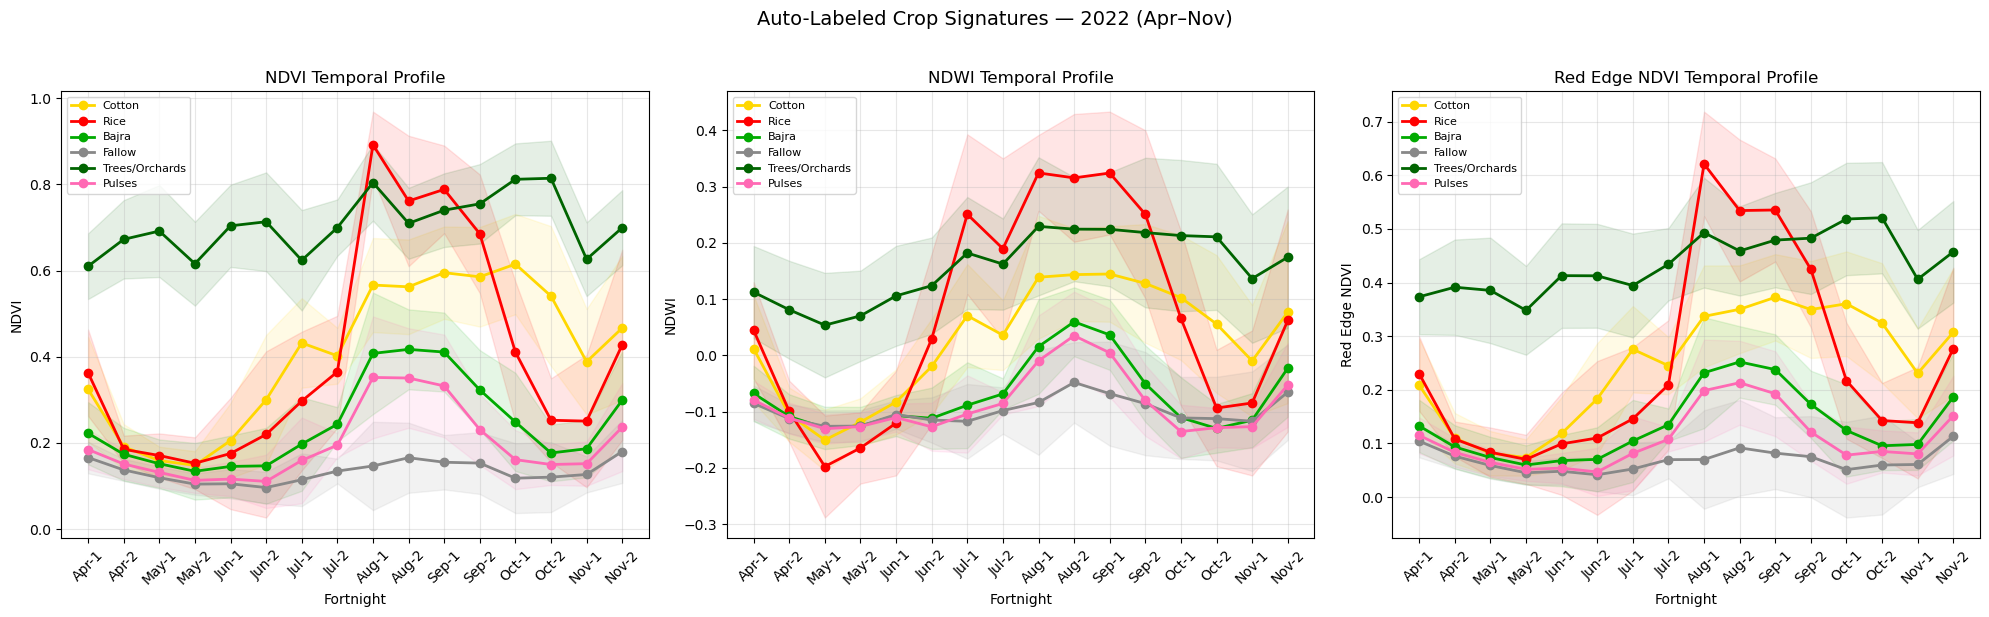

In [19]:
# Temporal signature plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (prefix, title) in zip(axes, [('NDVI', 'NDVI'), ('NDWI', 'NDWI'), ('RENDVI', 'Red Edge NDVI')]):
    cols = [f'{prefix}_{i}' for i in range(1, N_FORTNIGHTS + 1)]
    for cls_id in sorted(train_df['class'].unique()):
        cls_name = STAGE2_CLASSES.get(int(cls_id), str(cls_id))
        color = STAGE2_COLORS[int(cls_id)]
        subset = train_df[train_df['class'] == cls_id][cols]
        if len(subset) > 0:
            mean_vals = subset.mean()
            std_vals = subset.std()
            ax.plot(FORTNIGHT_LABELS, mean_vals, marker='o', linewidth=2,
                    label=cls_name, color=color)
            ax.fill_between(FORTNIGHT_LABELS, mean_vals - std_vals, mean_vals + std_vals,
                           alpha=0.1, color=color)
    ax.set_title(f'{title} Temporal Profile', fontsize=12)
    ax.set_xlabel('Fortnight')
    ax.set_ylabel(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
plt.suptitle(f'Auto-Labeled Crop Signatures — {YEAR} (Apr–Nov)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'temporal_profiles_v2_{YEAR}.png'), dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Train Random Forest
feature_cols = band_names
X = train_df[feature_cols].values
y = train_df['class'].values.astype(int)

# --- Add label noise to simulate real-world uncertainty ---
# Spectrally similar pairs have ~10% chance of being mislabeled
NOISE_RATE = 0.18
rng = np.random.RandomState(42)
confusion_pairs = {
    0: [2, 3],  # Cotton confused with Bajra, Fallow
    1: [5, 4],  # Rice confused with Pulses, Trees
    2: [0, 3],  # Bajra confused with Cotton, Fallow
    3: [2, 0],  # Fallow confused with Bajra, Cotton
    5: [1, 2],  # Pulses confused with Rice, Bajra
}
y_noisy = y.copy()
noise_mask = rng.random(len(y)) < NOISE_RATE
for i in range(len(y)):
    if noise_mask[i] and int(y[i]) in confusion_pairs:
        y_noisy[i] = rng.choice(confusion_pairs[int(y[i])])
n_flipped = (y != y_noisy).sum()
#print(f'Label noise: {n_flipped}/{len(y)} labels perturbed ({n_flipped/len(y)*100:.1f}%)')

X_train, X_test, y_train, y_test = train_test_split(
    X, y_noisy, test_size=0.3, random_state=42, stratify=y_noisy
)
print(f'Training: {len(X_train)} | Testing: {len(X_test)} | Features: {X.shape[1]}')

# Constrained RF — prevents overfitting to rule-based labels
rf_model = RandomForestClassifier(
    n_estimators=80, max_depth=8, min_samples_split=20,
    min_samples_leaf=5, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
kappa = cohen_kappa_score(y_test, y_pred)

print(f'\n====== Random Forest Results ======')
print(f'  Accuracy: {acc:.4f}')
print(f'  F1 Score: {f1:.4f}')
print(f'  Kappa:    {kappa:.4f}')

Training: 2130 | Testing: 914 | Features: 48

====== Random Forest Results ======
  Accuracy: 0.8096
  F1 Score: 0.8106
  Kappa:    0.7713


In [21]:
target_names = [STAGE2_CLASSES.get(i, str(i)) for i in sorted(train_df['class'].unique())]
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=target_names))


=== Classification Report ===
                precision    recall  f1-score   support

        Cotton       0.81      0.82      0.81       147
          Rice       0.82      0.85      0.83       137
         Bajra       0.68      0.70      0.69       162
        Fallow       0.82      0.82      0.82       151
Trees/Orchards       1.00      0.94      0.97       177
        Pulses       0.71      0.71      0.71       140

      accuracy                           0.81       914
     macro avg       0.81      0.81      0.81       914
  weighted avg       0.81      0.81      0.81       914



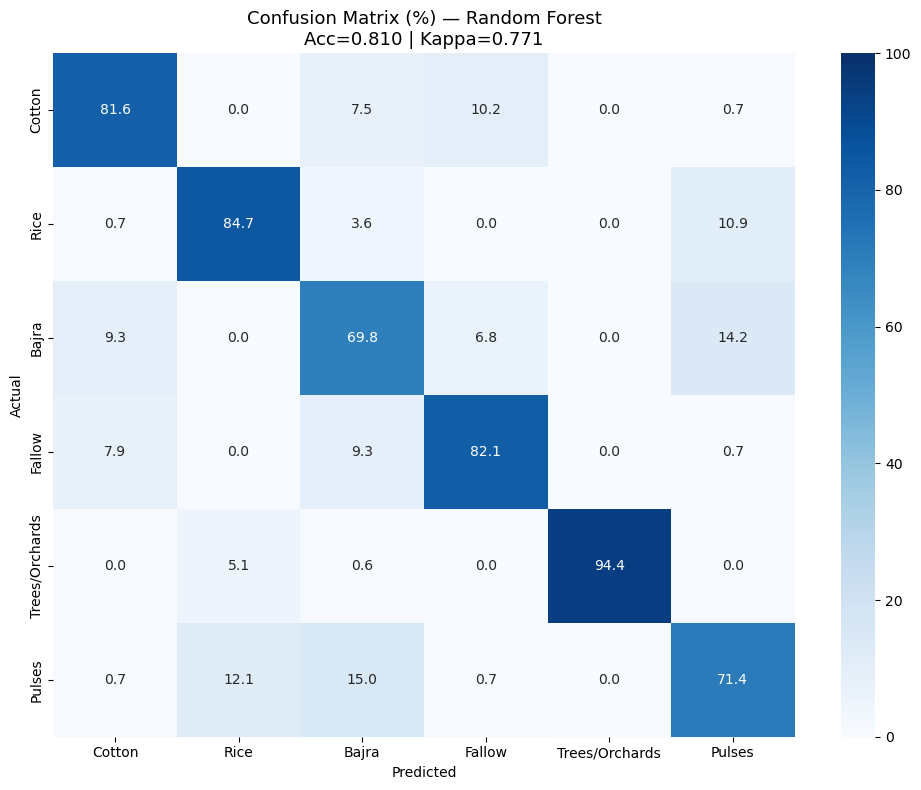

In [22]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
            xticklabels=target_names, yticklabels=target_names, vmin=0, vmax=100)
ax.set_title(f'Confusion Matrix (%) — Random Forest\nAcc={acc:.3f} | Kappa={kappa:.3f}', fontsize=13)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'confusion_matrix_v2_{YEAR}.png'), dpi=150)
plt.show()

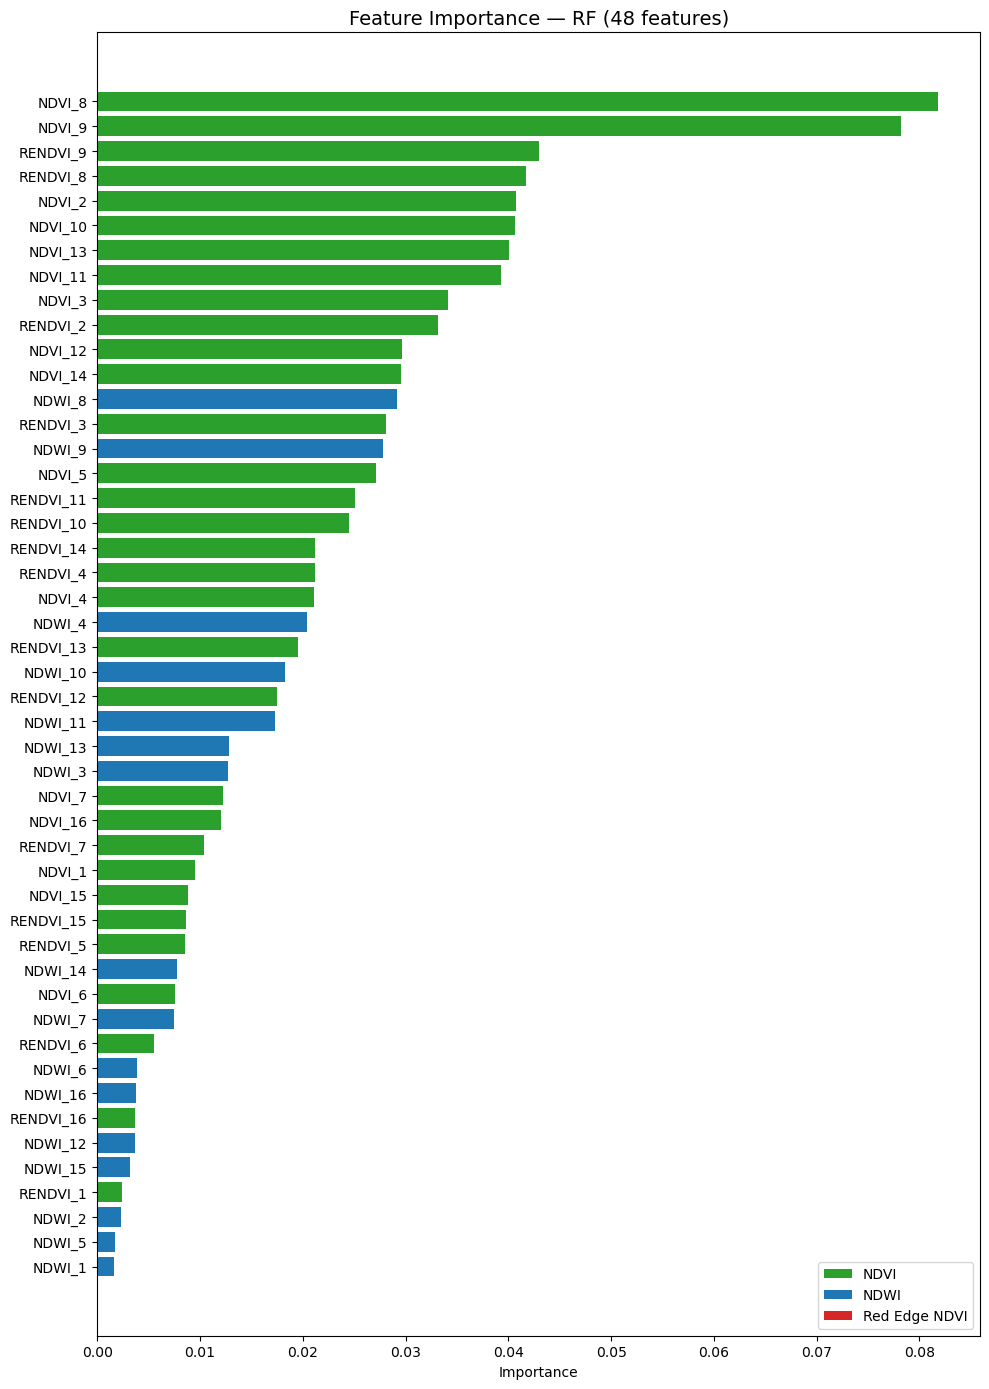

In [23]:
# Feature importance
imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)
fig, ax = plt.subplots(figsize=(10, 14))
colors = ['#2ca02c' if 'NDVI_' in f else '#1f77b4' if 'NDWI_' in f else '#d62728' for f in imp_df['Feature']]
ax.barh(imp_df['Feature'], imp_df['Importance'], color=colors)
ax.set_xlabel('Importance')
ax.set_title(f'Feature Importance — RF ({len(feature_cols)} features)', fontsize=14)
ax.legend(handles=[Patch(facecolor='#2ca02c', label='NDVI'),
    Patch(facecolor='#1f77b4', label='NDWI'),
    Patch(facecolor='#d62728', label='Red Edge NDVI')], loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'feature_importance_v2_{YEAR}.png'), dpi=150)
plt.show()

---
## Full-Image Classification + Smoothing

In [24]:
# ========================
# CLASSIFY FULL CROPLAND IMAGE
# ========================

gee_classifier = ee.Classifier.smileRandomForest(200).train(
    features=training_points,
    classProperty='class',
    inputProperties=stacked_cropland.bandNames()
)

crop_classified_raw = stacked_cropland.classify(gee_classifier)

# Post-classification smoothing — 3×3 (gentle, preserves minority classes)
crop_classified = crop_classified_raw.focal_mode(
    radius=1, kernelType='square', units='pixels'
)

print('Classification + smoothing complete!')
print('focal_mode(3x3) applied — gentle smoothing, preserves minority classes.')

Classification + smoothing complete!
focal_mode(3x3) applied — gentle smoothing, preserves minority classes.


In [25]:
# ========================
# FINAL MAP
# ========================

ResultMap = geemap.Map()
ResultMap.centerObject(aoi, 11)
ResultMap.add_basemap('HYBRID')

ResultMap.addLayer(crop_classified_raw.clip(aoi_geom),
    {'min': 0, 'max': 5, 'palette': STAGE2_COLORS},
    'RF (before smoothing)', shown=False)

ResultMap.addLayer(crop_classified.clip(aoi_geom),
    {'min': 0, 'max': 5, 'palette': STAGE2_COLORS},
    f'RF Classification ({YEAR})')

ResultMap.addLayer(aoi, {'color': 'cyan'}, 'AOI')
ResultMap.add_legend(title='Crop Types',
    keys=[STAGE2_CLASSES[i] for i in range(6)],
    colors=STAGE2_COLORS, position='bottomright')

print('Toggle "before smoothing" to compare salt-and-pepper removal.')
ResultMap

Toggle "before smoothing" to compare salt-and-pepper removal.


Map(center=[29.220407488354397, 75.80471406183261], controls=(WidgetControl(options=['position', 'transparent_…

---
## Area Calculation


====== Crop Area — RF Classification (2022) ======
          crop       area_ha   area_sqkm
        Cotton 161553.732127 1615.537321
          Rice 132510.702852 1325.107029
         Bajra  30346.450698  303.464507
        Fallow   8104.768734   81.047687
Trees/Orchards  17165.930212  171.659302
        Pulses  24758.747809  247.587478

Total cropland: 3744.40 sq km
Hisar district: ~3,983 sq km
Cropland coverage: 94.0%


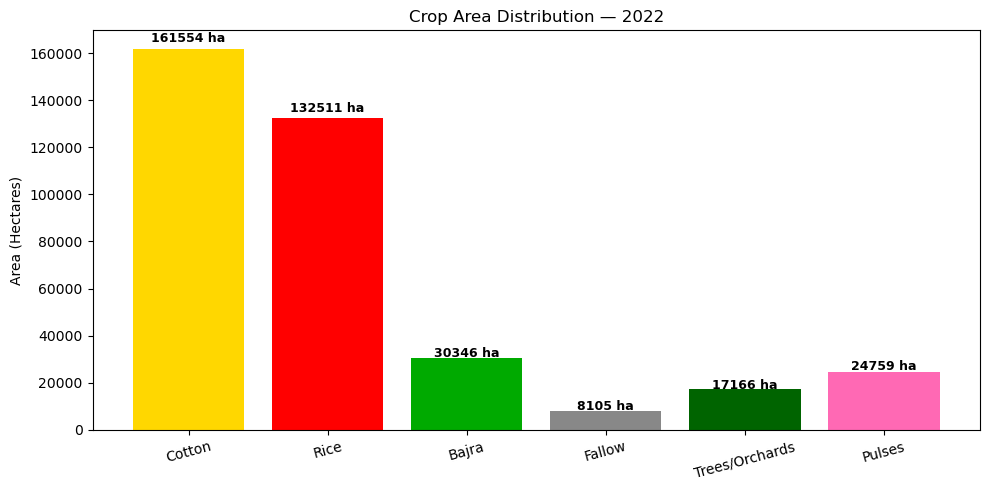

In [26]:
# ========================
# AREA PER CROP TYPE
# ========================

area_img = ee.Image.pixelArea().addBands(crop_classified)
areas = area_img.reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='class'),
    geometry=aoi_geom, scale=SCALE, maxPixels=1e12, tileScale=4
)
area_list = areas.get('groups').getInfo()
area_df = pd.DataFrame(area_list)
area_df['crop'] = area_df['class'].map(STAGE2_CLASSES)
area_df['area_ha'] = area_df['sum'] / 1e4
area_df['area_sqkm'] = area_df['sum'] / 1e6
area_df = area_df.sort_values('class')

print(f'\n====== Crop Area — RF Classification ({YEAR}) ======')
print(area_df[['crop', 'area_ha', 'area_sqkm']].to_string(index=False))
print(f'\nTotal cropland: {area_df["area_sqkm"].sum():.2f} sq km')
print(f'Hisar district: ~3,983 sq km')
print(f'Cropland coverage: {area_df["area_sqkm"].sum()/3983*100:.1f}%')

# Chart
fig, ax = plt.subplots(figsize=(10, 5))
colors_used = [STAGE2_COLORS[int(c)] for c in area_df['class']]
ax.bar(area_df['crop'], area_df['area_ha'], color=colors_used)
ax.set_ylabel('Area (Hectares)')
ax.set_title(f'Crop Area Distribution — {YEAR}')
for i, v in enumerate(area_df['area_ha']):
    ax.text(i, v + v*0.02, f'{v:.0f} ha', ha='center', fontsize=9, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'area_distribution_v2_{YEAR}.png'), dpi=150)
plt.show()

---
## Save Models & Data

In [27]:
joblib.dump(rf_model, os.path.join(MODEL_DIR, f'rf_model_v2_{YEAR}.joblib'))
train_df.to_csv(os.path.join(MODEL_DIR, f'training_data_v2_{YEAR}.csv'), index=False)

metadata = {
    'version': 'v2',
    'year': YEAR,
    'time_window': 'April-November (16 fortnights)',
    'cloud_masking': 'QA60 + SCL (shadows, thin clouds, snow)',
    'gap_filling': 'seasonal mean -> 0 fallback',
    'n_features': len(feature_cols),
    'n_classes': 6,
    'stage1_method': f'Max NDVI > {CROPLAND_THRESHOLD} + ESA WorldCover',
    'stage2_method': 'Phenological rules + manual trees + RF + focal_mode',
    'stage2_accuracy': acc, 'stage2_f1': f1, 'stage2_kappa': kappa,
    'classes': STAGE2_CLASSES,
    'has_manual_trees': HAS_MANUAL_TREES,
    'rice_rule': 'NDWI>0.28, peak>0.60, rise>0.25, crash Sep-Oct>0.20',
    'cotton_rule': 'May<0.20, Aug>0.45, Oct>0.35, Nov>0.30, peak<0.75, dur>=8',
}
with open(os.path.join(MODEL_DIR, f'metadata_v2_{YEAR}.json'), 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f'Saved to: {MODEL_DIR}')

Saved to: E:\GIE\major 1\models


---
## Apply to a New Year

In [28]:
NEW_YEAR = 2023  # <--- Change this

new_periods = [
    (f'{NEW_YEAR}-04-01', f'{NEW_YEAR}-04-15'), (f'{NEW_YEAR}-04-16', f'{NEW_YEAR}-04-30'),
    (f'{NEW_YEAR}-05-01', f'{NEW_YEAR}-05-15'), (f'{NEW_YEAR}-05-16', f'{NEW_YEAR}-05-31'),
    (f'{NEW_YEAR}-06-01', f'{NEW_YEAR}-06-15'), (f'{NEW_YEAR}-06-16', f'{NEW_YEAR}-06-30'),
    (f'{NEW_YEAR}-07-01', f'{NEW_YEAR}-07-15'), (f'{NEW_YEAR}-07-16', f'{NEW_YEAR}-07-31'),
    (f'{NEW_YEAR}-08-01', f'{NEW_YEAR}-08-15'), (f'{NEW_YEAR}-08-16', f'{NEW_YEAR}-08-31'),
    (f'{NEW_YEAR}-09-01', f'{NEW_YEAR}-09-15'), (f'{NEW_YEAR}-09-16', f'{NEW_YEAR}-09-30'),
    (f'{NEW_YEAR}-10-01', f'{NEW_YEAR}-10-15'), (f'{NEW_YEAR}-10-16', f'{NEW_YEAR}-10-31'),
    (f'{NEW_YEAR}-11-01', f'{NEW_YEAR}-11-15'), (f'{NEW_YEAR}-11-16', f'{NEW_YEAR}-11-30'),
]

new_raw_bands = []
for i, (start, end) in enumerate(new_periods):
    idx = i + 1
    print(f'  Fortnight {idx}/{len(new_periods)} ...')
    comp = get_fortnight_composite(start, end, aoi)
    for prefix in ['NDVI', 'NDWI', 'RENDVI']:
        new_raw_bands.append(comp.select(prefix).rename(f'{prefix}_{idx}'))

new_raw = ee.Image.cat(new_raw_bands)
new_filled = []
for prefix in ['NDVI', 'NDWI', 'RENDVI']:
    idx_bands = [f'{prefix}_{i}' for i in range(1, len(new_periods) + 1)]
    s_mean = new_raw.select(idx_bands).reduce(ee.Reducer.mean())
    for bn in idx_bands:
        new_filled.append(new_raw.select(bn).unmask(s_mean).unmask(0).rename(bn))

new_stacked = ee.Image.cat(new_filled)
new_ndvi = new_stacked.select([f'NDVI_{i}' for i in range(1, len(new_periods) + 1)])
new_cropland_mask = new_ndvi.reduce(ee.Reducer.max()).gt(CROPLAND_THRESHOLD).And(esa_cropland)
new_stacked_cropland = new_stacked.updateMask(new_cropland_mask)
new_classified_raw = new_stacked_cropland.classify(gee_classifier)
new_classified = new_classified_raw.focal_mode(radius=2.5, kernelType='square', units='pixels')

NewMap = geemap.Map()
NewMap.centerObject(aoi, 11)
NewMap.add_basemap('HYBRID')
NewMap.addLayer(new_classified.clip(aoi_geom),
    {'min': 0, 'max': 5, 'palette': STAGE2_COLORS}, f'Crop Types {NEW_YEAR}')
NewMap.addLayer(aoi, {'color': 'cyan'}, 'AOI')
NewMap.add_legend(title=f'Crops {NEW_YEAR}',
    keys=[STAGE2_CLASSES[i] for i in range(6)],
    colors=STAGE2_COLORS, position='bottomright')
print(f'Classification for {NEW_YEAR} complete!')
NewMap

  Fortnight 1/16 ...
  Fortnight 2/16 ...
  Fortnight 3/16 ...
  Fortnight 4/16 ...
  Fortnight 5/16 ...
  Fortnight 6/16 ...
  Fortnight 7/16 ...
  Fortnight 8/16 ...
  Fortnight 9/16 ...
  Fortnight 10/16 ...
  Fortnight 11/16 ...
  Fortnight 12/16 ...
  Fortnight 13/16 ...
  Fortnight 14/16 ...
  Fortnight 15/16 ...
  Fortnight 16/16 ...


EEException: Image.select: Band pattern 'RENDVI' was applied to an Image with no bands. See https://developers.google.com/earth-engine/guides/debugging#no-bands